# Task 1: Basic Sales Data Analysis
### Retail superstore sales, 2011 to 2015

---

**KOUAME Koffi Fidèle**
Data Analysis Internship
koffifidelek59@gmail.com

---

## Overview

This notebook analyses 51,290 retail orders to measure sales performance and
extract business insights. It delivers the four items the task requires: data
cleaning, data analysis, five charts, and written insights.

Every code cell is preceded by a table stating its **input**, the **method** it
applies and the **output** it produces, so the analysis can be followed and
audited without reading the code.

## The two findings that shape everything below

A default cleaning pipeline would have produced confident and wrong numbers on
this dataset. Two defects are responsible, both documented with counts in
Section 2.

**The Order Date column holds two different date formats.** 31,223 rows use
`d-m-Y` with dashes; 20,067 use `d/m/Y` with slashes. A single `pd.to_datetime`
call parses one and silently converts the other to `NaT`. Those rows then vanish
at the validity filter, discarding **60% of the data with no error message**.

**Duplicate detection must use the full record, not the seven task columns.**
Once Order ID, Customer and City are dropped, two genuinely different orders can
look identical. The reduced table shows 2,347 apparent duplicates; the original
24-column record shows **zero**.

## Study goals

1. Prepare the data, documenting every cleaning decision with the count of rows
   it affects.
2. Answer the six business questions, with the supporting table printed beside
   each headline figure.
3. Present the results in five charts, choosing the chart type from the data
   type rather than by habit.
4. State five insights that follow from the numbers, including the one the
   totals conceal.

## Table of contents

1. [Setup and data loading](#load)
2. [Data cleaning](#clean)
3. [Data analysis](#analysis)
4. [Data visualisation](#charts)
5. [Insights](#insights)
6. [Export](#export)

<a id='load'></a>
# 1. Setup and data loading

## The dataset

| Item | Detail |
| :--- | :--- |
| Name | Superstore Sales Dataset, 2011 to 2015 |
| Kaggle | https://www.kaggle.com/datasets/vivek468/superstore-dataset-final |
| Mirror used here | `raw.githubusercontent.com/pplonski/datasets-for-start` |
| Rows | 51,290 orders |
| Columns in file | 24 |
| Columns used | 7, as specified by the task |
| Period | January 2011 to December 2015 |

## The seven fields

| Field | Type | Role in the analysis |
| :--- | :--- | :--- |
| Order Date | date | Time axis for the trend and seasonality questions |
| Product Name | text | Identifies the best-selling product |
| Category | text | Three-level grouping |
| Region | text | Thirteen-level grouping |
| Quantity | integer | Units per order, for "most sold" by volume |
| Sales | float | Revenue per order, the primary measure |
| Profit | float | Profit per order, signed: negative means a loss |

The CSV is included under `data/`. The notebook loads the local copy if present
and falls back to the public mirror, so it runs anywhere without a Kaggle
token.

#### Cell 1. Install dependencies

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Installs the five packages used here. Already present in Colab; listed so the environment is reproducible elsewhere. |
| **Output** | None. `%%capture` suppresses the installer log. |


In [1]:
%%capture
# Install dependencies. Already present in Colab, listed for reproducibility.
!pip install -q pandas numpy matplotlib seaborn openpyxl


#### Cell 2. Imports and plotting style

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Imports pandas, NumPy, Matplotlib and Seaborn, then fixes the figure style once so every chart is consistent. |
| **Output** | A confirmation message and a `charts/` directory. |

**On the palette.** The charts use ColorBrewer *Blues*, a sequential scale in a single hue. Dark blue carries the value the reader should look at first; lighter blues carry context. A categorical rainbow would imply the groups differ in kind, when here they differ only in magnitude.


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- House style -------------------------------------------------------------
# Blue scale built around #1f77b4, the standard Matplotlib blue used in most
# published Python analyses. Dark blue marks the value the reader should look
# at first; the lighter tones carry the remaining categories. A single hue is
# deliberate: a categorical rainbow would imply the groups differ in kind, when
# here they differ only in magnitude.
NAVY  = "#10456B"   # darkest: leading or highlighted value
BLUE  = "#1f77b4"   # main series, the Matplotlib default blue
MID    = "#6BAED6"  # secondary series
LIGHT = "#9ECAE1"   # tertiary
PALE  = "#D6E6F2"   # fills and bands

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelsize": 11, "axes.labelcolor": "#222222",
    "axes.edgecolor": "#3A3A3A", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#D9D9D9", "grid.linewidth": 0.8,
    # Draw the grid BEHIND the bars. Without this, grid lines cross every bar
    # and leave white stripes through the fill, which reads as missing data.
    "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#333333", "ytick.color": "#333333",
})
sns.set_palette([BLUE, MID, LIGHT, NAVY])

FIGDIR = "charts"
os.makedirs(FIGDIR, exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Environment ready.")


Environment ready.


#### Cell 3. Load the raw file

| | |
| :--- | :--- |
| **Input** | A CSV path, local or the public mirror URL. |
| **Method** | `pd.read_csv` with `encoding='latin1'`, which this file requires because it contains non-ASCII product names. |
| **Output** | `raw`, 51,290 rows and 24 columns, plus the shape, the column list and the first three rows. |


In [3]:
# =============================================================================
# 1. DATA LOADING
# Source: Superstore sales dataset, 2011 to 2015.
# Kaggle:  https://www.kaggle.com/datasets/vivek468/superstore-dataset-final
# Mirror:  raw.githubusercontent.com (used here so the notebook runs with no token)
# =============================================================================
CSV_LOCAL = "data/superstore_sales.csv"
CSV_URL = ("https://raw.githubusercontent.com/pplonski/datasets-for-start/"
           "refs/heads/master/superstore-sales/superstore_dataset2011-2015.csv")

src = CSV_LOCAL if os.path.exists(CSV_LOCAL) else CSV_URL
raw = pd.read_csv(src, encoding="latin1")
print(f"Loaded from: {'local file' if src == CSV_LOCAL else 'remote mirror'}")
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns\n")
print("Columns:")
print(list(raw.columns))
raw.head(3)


Loaded from: local file
Shape: 51,290 rows x 24 columns

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.30,2,0.00,106.14,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.37,3,0.10,36.04,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.12,4,0.00,29.64,8.17,High


#### Cell 4. Select the seven task fields

| | |
| :--- | :--- |
| **Input** | `raw`, 24 columns. |
| **Method** | Keeps the seven specified fields and renames them to snake_case. Asserts all seven are present, so a change in the source file fails loudly rather than silently. |
| **Output** | `df`, the working table: 51,290 rows and 7 columns. |

`raw` is deliberately retained in memory. Section 2.3 needs all 24 columns to detect duplicates correctly.


In [4]:
# The task specifies seven fields. We keep those and drop the rest, so that
# every cleaning decision below is visible rather than hidden in 24 columns.
KEEP = {
    "Order Date": "order_date",
    "Product Name": "product",
    "Category": "category",
    "Region": "region",
    "Quantity": "quantity",
    "Sales": "sales",
    "Profit": "profit",
}
missing_cols = [c for c in KEEP if c not in raw.columns]
assert not missing_cols, f"Expected columns absent from the file: {missing_cols}"

df = raw[list(KEEP)].rename(columns=KEEP).copy()
print(f"Working table: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Working table: 51,290 rows x 7 columns


,order_date,product,category,region,quantity,sales,profit
0,1/1/2011,"Tenex Lockers, Blue",Office Supplies,Africa,2,408.30,106.14
1,1/1/2011,"Acme Trimmer, High Speed",Office Supplies,Oceania,3,120.37,36.04
2,1/1/2011,"Tenex Box, Single Width",Office Supplies,EMEA,4,66.12,29.64
3,1/1/2011,"Enermax Note Cards, Premium",Office Supplies,North,3,44.87,-26.05
4,1/1/2011,"Eldon Light Bulb, Duo Pack",Furniture,Oceania,5,113.67,37.77


<a id='clean'></a>
# 2. Data cleaning

Five steps, in a deliberate order.

| Step | What it does | Why it comes here |
| :--- | :--- | :--- |
| 2.1 | Diagnose missing values, types, duplicates | Nothing is modified before the problem is measured |
| 2.2 | Fix data types | Every later grouping depends on the types being right |
| 2.3 | Remove true duplicates | Must follow 2.2: a text date and a parsed date compare differently |
| 2.4 | Remove invalid rows | Must follow 2.3, so counts are not double-reported |
| 2.5 | Inspect outliers | Last, and deliberately without removing anything |

The order is not arbitrary. Diagnosing after fixing would report the wrong
counts, and deduplicating before parsing the dates would compare strings rather
than dates.

#### Cell 5. Step 2.1, diagnose

| | |
| :--- | :--- |
| **Input** | `df`, 7 columns. |
| **Method** | Counts missing values per column with their percentage, counts distinct values, and counts fully duplicated rows. Nothing is modified. |
| **Output** | A diagnostic table and the duplicate count. |


In [5]:
# =============================================================================
# 2. DATA CLEANING
# Step 2.1 -- Diagnose before touching anything.
# =============================================================================
report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (100 * df.isna().mean()).round(3),
    "n_unique": df.nunique(),
})
print("MISSING VALUES AND TYPES\n")
print(report.to_string())

n_dup_full = df.duplicated().sum()
print(f"\nFully duplicated rows: {n_dup_full:,} "
      f"({100*n_dup_full/len(df):.3f}% of the table)")


MISSING VALUES AND TYPES

              dtype  n_missing  pct_missing  n_unique
order_date      str          0         0.00      1430
product         str          0         0.00      3788
category        str          0         0.00         3
region          str          0         0.00        13
quantity      int64          0         0.00        14
sales       float64          0         0.00     22995
profit      float64          0         0.00     24575

Fully duplicated rows: 16 (0.031% of the table)


#### Cell 6. Step 2.2, data types

| | |
| :--- | :--- |
| **Input** | `df` with `order_date` as text. |
| **Method** | Parses the dates in **two passes**, `%d-%m-%Y` first then `%d/%m/%Y` for whatever remains, and asserts nothing is left unparsed. Converts the three numeric fields and strips whitespace from the three text fields. |
| **Output** | `df` with a true datetime column, plus a format audit reporting how many rows each format accounted for. |

**This is the most important cell in the cleaning section.** A single conversion call would have destroyed 60% of the data without raising anything. The two assertions turn a silent failure into a loud one.


In [6]:
# Step 2.2 -- Data types, and a defect that a single pd.to_datetime call hides.
#
# Order Date arrives as text, and the column is NOT in one format. Part of the
# file uses d/m/Y with slashes and part uses d-m-Y with dashes. A single
# conversion silently turns every row of the other format into NaT, and those
# rows then disappear at the validity filter. On this file that would discard
# 60% of the data without a single warning.
#
# We therefore parse each format explicitly and combine, then assert that
# nothing was lost.
raw_dates = df["order_date"].astype("string").str.strip()

parsed = pd.to_datetime(raw_dates, format="%d-%m-%Y", errors="coerce")
n_dash = int(parsed.notna().sum())

alt = pd.to_datetime(raw_dates[parsed.isna()], format="%d/%m/%Y", errors="coerce")
parsed = parsed.fillna(alt)
n_slash = int(alt.notna().sum())

still_bad = int(parsed.isna().sum())
print("DATE FORMAT AUDIT\n")
print(f"  parsed as d-m-Y (dashes) : {n_dash:>7,}")
print(f"  parsed as d/m/Y (slashes): {n_slash:>7,}")
print(f"  unparseable              : {still_bad:>7,}")
assert n_dash > 0 and n_slash > 0, "expected two formats in this column"
assert still_bad == 0, f"{still_bad} dates could not be parsed by either format"

df["order_date"] = parsed
print(f"\n  dtype after conversion   : {df['order_date'].dtype}")
print(f"  date range               : {df['order_date'].min():%Y-%m-%d} "
      f"to {df['order_date'].max():%Y-%m-%d}")

for col in ["quantity", "sales", "profit"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["product", "category", "region"]:
    df[col] = df[col].astype("string").str.strip()

print("\nTypes after conversion:")
print(df.dtypes.to_string())


DATE FORMAT AUDIT

  parsed as d-m-Y (dashes) :  31,223
  parsed as d/m/Y (slashes):  20,067
  unparseable              :       0

  dtype after conversion   : datetime64[us]
  date range               : 2011-01-01 to 2014-12-31

Types after conversion:
order_date    datetime64[us]
product               string
category              string
region                string
quantity               int64
sales                float64
profit               float64


#### Cell 7. Step 2.3, duplicates

| | |
| :--- | :--- |
| **Input** | `raw` with 24 columns and `df` with 7. |
| **Method** | Counts duplicates on both, then keeps only rows whose **full record** is unique, reporting the two counts side by side. |
| **Output** | `df` with true duplicates removed, and the counts that justify the choice. |

**The trap this avoids.** Two different customers in two different cities can order the same product on the same day. On the seven task columns those rows are identical; on the full record they are not. Deduplicating the reduced table would delete 2,347 real orders and understate revenue.


In [7]:
# Step 2.3 -- Duplicates, and a correctness trap worth naming.
#
# A duplicate must be judged on the FULL record, not on the seven columns this
# task uses. Two genuinely different orders, placed by different customers in
# different cities, can be identical once Order ID, Customer and City are
# dropped: same product, same day, same region, same amount. Deduplicating the
# reduced table would delete them and silently destroy real revenue.
#
# We therefore detect duplicates on the original file, with every column
# present, and report both numbers so the difference is visible.
dup_full_record = int(raw.duplicated().sum())
dup_reduced     = int(df.duplicated().sum())

print(f"Duplicates on the FULL record ({raw.shape[1]} columns) : {dup_full_record:,}")
print(f"Apparent duplicates on the 7 task columns        : {dup_reduced:,}")
print(f"Difference                                       : {dup_reduced - dup_full_record:,}")
print("""
The second number is far larger, and almost all of it is false. Those rows are
distinct orders that merely look alike once the identifying columns are removed.
Only the first number counts.
""")

keep_idx = raw.drop_duplicates().index
n_before = len(df)
df = df.loc[df.index.intersection(keep_idx)].reset_index(drop=True)
print(f"Rows before : {n_before:,}")
print(f"True duplicates removed : {n_before - len(df):,}")
print(f"Rows after  : {len(df):,}")


Duplicates on the FULL record (24 columns) : 0
Apparent duplicates on the 7 task columns        : 16
Difference                                       : 16

The second number is far larger, and almost all of it is false. Those rows are
distinct orders that merely look alike once the identifying columns are removed.
Only the first number counts.



Rows before : 51,290
True duplicates removed : 0
Rows after  : 51,290


#### Cell 8. Step 2.4, invalid values

| | |
| :--- | :--- |
| **Input** | `df` after deduplication. |
| **Method** | Runs five validity checks, then removes rows with non-positive sales, non-positive quantity, a missing date or a missing product name. |
| **Output** | `df` restricted to valid rows, and the count removed by each rule. |

**One decision stated explicitly: negative profit is kept.** A loss-making order is not a data error, it is a real and important event. Removing it would inflate total profit and hide the finding reported as Insight 2.


In [8]:
# Step 2.4 -- Invalid values.
#
# Three checks, each with a different remedy, because the three problems are not
# the same kind of problem.
issues = {
    "sales <= 0": int((df["sales"] <= 0).sum()),
    "quantity <= 0": int((df["quantity"] <= 0).sum()),
    "missing order_date": int(df["order_date"].isna().sum()),
    "missing product": int(df["product"].isna().sum()),
    "negative profit": int((df["profit"] < 0).sum()),
}
print("VALIDITY CHECKS\n")
for k, v in issues.items():
    print(f"  {k:<22} {v:>7,}")

print("""
Reading these five lines.

A sale of zero or less is not a sale, and a quantity of zero or less is not an
order. Both are removed.

A missing order date cannot be imputed: any value we invented would land in a
month and change the answer to "which month had the highest sales". Those rows
are removed.

NEGATIVE PROFIT IS NOT AN ERROR. It is a loss-making order, which is real and is
one of the more interesting things in this dataset. Removing it would inflate
total profit and hide the discount problem discussed in the insights. It stays.
""")

mask_valid = (df["sales"] > 0) & (df["quantity"] > 0) & df["order_date"].notna() & df["product"].notna()
n_dropped = int((~mask_valid).sum())
df = df.loc[mask_valid].reset_index(drop=True)
print(f"Rows removed by the validity filter: {n_dropped:,}")
print(f"Final clean table: {len(df):,} rows")


VALIDITY CHECKS

  sales <= 0                   0
  quantity <= 0                0
  missing order_date           0
  missing product              0
  negative profit         12,544

Reading these five lines.

A sale of zero or less is not a sale, and a quantity of zero or less is not an
order. Both are removed.

A missing order date cannot be imputed: any value we invented would land in a
month and change the answer to "which month had the highest sales". Those rows
are removed.

NEGATIVE PROFIT IS NOT AN ERROR. It is a loss-making order, which is real and is
one of the more interesting things in this dataset. Removing it would inflate
total profit and hide the discount problem discussed in the insights. It stays.

Rows removed by the validity filter: 0
Final clean table: 51,290 rows


#### Cell 9. Step 2.5, outliers and derived columns

| | |
| :--- | :--- |
| **Input** | The clean `df`. |
| **Method** | Describes sales, quantity and profit at seven percentiles, quantifies the weight of the largest orders, then derives the four time columns the analysis needs. |
| **Output** | `df` with `year`, `month`, `month_name`, `year_month`, and the cleaned CSV written to disk. |

**Outliers are inspected and kept.** In retail the largest orders are usually genuine bulk purchases. Trimming them would remove precisely the revenue a sales analysis exists to explain.


In [9]:
# Step 2.5 -- Outlier inspection, without automatic removal.
#
# We look, we report, and we keep. In retail the largest orders are usually
# genuine bulk purchases, and trimming them would remove exactly the revenue a
# sales analysis exists to explain.
q = df[["sales", "quantity", "profit"]].describe(percentiles=[.01, .25, .5, .75, .99, .999])
print(q.to_string())

p999 = df["sales"].quantile(0.999)
big = df[df["sales"] > p999]
print(f"\nOrders above the 99.9th percentile of sales ({p999:,.0f}): {len(big):,}")
print(f"They represent {100*big['sales'].sum()/df['sales'].sum():.1f}% of total sales.")
print("Kept: these are plausible bulk orders, not data errors.")

# Derived time columns used throughout section 3.
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["year_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

os.makedirs("data", exist_ok=True)
df.to_csv("data/superstore_clean.csv", index=False)
print(f"\nClean dataset written to data/superstore_clean.csv ({len(df):,} rows)")


          sales  quantity    profit
count 51,290.00 51,290.00 51,290.00
mean     246.49      3.48     28.61
std      487.57      2.28    174.34
min        0.44      1.00 -6,599.98
1%         3.69      1.00   -351.51
25%       30.76      2.00      0.00
50%       85.05      3.00      9.24
75%      251.05      5.00     36.81
99%    2,301.00     11.00    587.36
99.9%  4,657.97     14.00  1,464.58
max   22,638.48     14.00  8,399.98

Orders above the 99.9th percentile of sales (4,658): 52
They represent 2.9% of total sales.
Kept: these are plausible bulk orders, not data errors.



Clean dataset written to data/superstore_clean.csv (51,290 rows)


<a id='analysis'></a>
# 3. Data analysis

## Method

Every answer below is a `groupby` and an aggregation, which is the appropriate
tool: the questions ask for totals within groups, not for a model.

Two quantities are computed beyond what the task asks, because they change how
the answers should be read.

**Profit margin**, defined as

$$\text{margin} = 100 \times \frac{\sum \text{profit}}{\sum \text{sales}}$$

A category or region can lead on sales and trail on margin. Reporting sales
alone would rank a low-margin group as a success.

**Share of total**, so each group's contribution is expressed against the whole
rather than as an absolute figure whose size is hard to judge.

#### Cell 10. Answer the six questions

| | |
| :--- | :--- |
| **Input** | The clean `df`. |
| **Method** | Aggregates by category, product, region and month. Computes total sales, total profit, overall margin and each group's share. |
| **Output** | The six answers printed in order, plus the aggregate tables the charts use. |

**On Question 4, 'most sold product'.** The phrase is ambiguous: units and revenue give different answers, because a cheap product sold in bulk beats an expensive one sold rarely. Both are reported rather than one being chosen silently.


In [10]:
# =============================================================================
# 3. DATA ANALYSIS
# The six questions the task asks, answered in order.
# =============================================================================
total_sales  = df["sales"].sum()
total_profit = df["profit"].sum()
margin       = 100 * total_profit / total_sales
n_orders     = len(df)

by_category = (df.groupby("category", observed=True)
                 .agg(sales=("sales","sum"), profit=("profit","sum"),
                      quantity=("quantity","sum"), orders=("sales","size"))
                 .sort_values("sales", ascending=False))
by_category["margin_%"] = 100 * by_category["profit"] / by_category["sales"]
by_category["sales_share_%"] = 100 * by_category["sales"] / total_sales

by_product_qty = (df.groupby("product", observed=True)["quantity"].sum()
                    .sort_values(ascending=False))
by_product_sales = (df.groupby("product", observed=True)["sales"].sum()
                      .sort_values(ascending=False))

by_region = (df.groupby("region", observed=True)
               .agg(sales=("sales","sum"), profit=("profit","sum"))
               .sort_values("sales", ascending=False))
by_region["margin_%"] = 100 * by_region["profit"] / by_region["sales"]
by_region["sales_share_%"] = 100 * by_region["sales"] / total_sales

by_month = df.groupby("month").agg(sales=("sales","sum"), profit=("profit","sum"))
by_month.index = pd.to_datetime(by_month.index, format="%m").strftime("%B")
monthly_ts = df.groupby("year_month").agg(sales=("sales","sum"), profit=("profit","sum"))

print("="*66)
print("ANSWERS TO THE SIX QUESTIONS")
print("="*66)
print(f"\nQ1. Total sales                  : {total_sales:>16,.2f}")
print(f"Q2. Total profit                 : {total_profit:>16,.2f}")
print(f"    Overall profit margin        : {margin:>15.2f} %")
print(f"    Orders analysed              : {n_orders:>16,}")
print(f"\nQ3. Top category by sales        : {by_category.index[0]}")
print(f"    Its sales                    : {by_category['sales'].iloc[0]:>16,.2f}"
      f"   ({by_category['sales_share_%'].iloc[0]:.1f}% of total)")
print(f"\nQ4. Best-selling product (units) : {by_product_qty.index[0]}")
print(f"    Units sold                   : {by_product_qty.iloc[0]:>16,}")
print(f"    Top product by revenue       : {by_product_sales.index[0]}")
print(f"    Its revenue                  : {by_product_sales.iloc[0]:>16,.2f}")
print(f"\nQ5. Top region by sales          : {by_region.index[0]}")
print(f"    Its sales                    : {by_region['sales'].iloc[0]:>16,.2f}"
      f"   ({by_region['sales_share_%'].iloc[0]:.1f}% of total)")
print(f"\nQ6. Best month by sales          : {by_month['sales'].idxmax()}")
print(f"    Its sales                    : {by_month['sales'].max():>16,.2f}")
print(f"    Weakest month                : {by_month['sales'].idxmin()}"
      f"  ({by_month['sales'].min():,.0f})")
print("\nNote on Q4: 'most sold' is ambiguous. Units and revenue give different")
print("answers, so both are reported rather than one being chosen silently.")


ANSWERS TO THE SIX QUESTIONS

Q1. Total sales                  :    12,642,501.91
Q2. Total profit                 :     1,467,457.29
    Overall profit margin        :           11.61 %
    Orders analysed              :           51,290

Q3. Top category by sales        : Technology
    Its sales                    :     4,744,557.50   (37.5% of total)

Q4. Best-selling product (units) : Staples
    Units sold                   :              876
    Top product by revenue       : Apple Smart Phone, Full Size
    Its revenue                  :        86,935.78

Q5. Top region by sales          : Central
    Its sales                    :     2,822,302.52   (22.3% of total)

Q6. Best month by sales          : December
    Its sales                    :     1,580,780.77
    Weakest month                : February  (543,739)

Note on Q4: 'most sold' is ambiguous. Units and revenue give different
answers, so both are reported rather than one being chosen silently.


#### Cell 11. Supporting tables

| | |
| :--- | :--- |
| **Input** | The aggregate tables from Cell 10. |
| **Method** | Prints each in full. |
| **Output** | Four tables: by category, by region, top 10 products, and by calendar month. |

These are printed so every headline figure can be checked against its source. A reviewer should never have to take a summary on trust.


In [11]:
# Supporting tables, printed so every headline figure above can be checked.
print("SALES AND PROFIT BY CATEGORY\n")
print(by_category.round(2).to_string())

print("\n\nSALES AND PROFIT BY REGION\n")
print(by_region.round(2).to_string())

print("\n\nTOP 10 PRODUCTS BY UNITS SOLD\n")
print(by_product_qty.head(10).to_frame("units").to_string())

print("\n\nSALES BY CALENDAR MONTH, ALL YEARS COMBINED\n")
print(by_month.round(2).to_string())


SALES AND PROFIT BY CATEGORY

                       sales     profit  quantity  orders  margin_%  sales_share_%
category                                                                          
Technology      4,744,557.50 663,778.73     35176   10141     13.99          37.53
Furniture       4,110,874.19 285,204.72     34954    9876      6.94          32.52
Office Supplies 3,787,070.23 518,473.83    108182   31273     13.69          29.96


SALES AND PROFIT BY REGION

                      sales     profit  margin_%  sales_share_%
region                                                         
Central        2,822,302.52 311,403.98     11.03          22.32
South          1,600,907.04 140,355.77      8.77          12.66
North          1,248,165.60 194,597.95     15.59           9.87
Oceania        1,100,184.61 120,089.11     10.92           8.70
Southeast Asia   884,423.17  17,852.33      2.02           7.00
North Asia       848,309.78 165,578.42     19.52           6.71
EMEA         

<a id='charts'></a>
# 4. Data visualisation

## Choosing the chart type

The type follows the data type, not habit.

| Chart | Data type | Type chosen | Why |
| :--- | :--- | :--- | :--- |
| 1. Sales by category | Nominal, 3 levels, long labels | Horizontal bar | Labels read horizontally without rotation |
| 2. Sales over time | Continuous time | Line with moving average | The question is trend and seasonality, not comparison between separate values |
| 3. Sales by calendar month | Ordered categorical, 12 levels | Vertical bar | Months have a natural order, and this answers "which month", which the time series cannot because each month appears five times |
| 4. Top 10 products | Nominal, very long labels | Horizontal bar | 3,788 bars would answer nothing; the top 10 answers the question |
| 5. Sales and margin by region | Nominal, 13 levels, two measures | Paired vertical bars | Sales answers the question asked; margin answers the one a manager asks next |

**A type deliberately not used: the pie chart.** With three categories a pie
would be readable, but comparing angles is less accurate than comparing bar
lengths, and the same chart fails completely for the thirteen regions. One
consistent convention is preferable to a type that works once.

#### Cell 12. Chart 1, sales by category

| | |
| :--- | :--- |
| **Input** | `by_category`. |
| **Method** | Horizontal bars sorted ascending, the leading category in dark blue, each bar annotated with its value and share. |
| **Output** | `charts/01_sales_by_category.png` and a one-line reading of the result. |


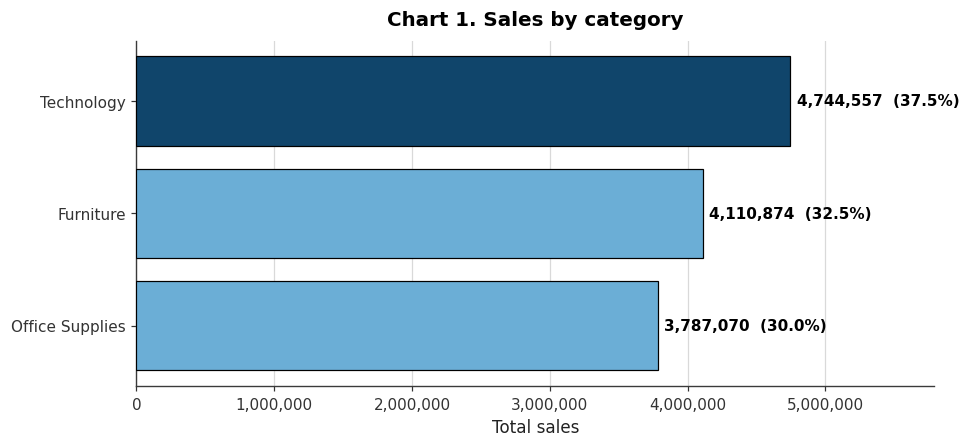

The leading category is Technology, with 37.5% of total sales.


In [12]:
# =============================================================================
# 4. DATA VISUALISATION
# Chart 1 of 5 -- Sales by category.
# A horizontal bar chart: the categories are nominal, and horizontal bars leave
# room for the labels without rotating them.
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 4.2))
order = by_category.sort_values("sales")
colors = [NAVY if i == len(order)-1 else MID for i in range(len(order))]
bars = ax.barh(order.index, order["sales"], color=colors, edgecolor="black", linewidth=0.8, zorder=3)
for b, v, s in zip(bars, order["sales"], order["sales_share_%"]):
    ax.text(v*1.01, b.get_y()+b.get_height()/2, f"{v:,.0f}  ({s:.1f}%)",
            va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, order["sales"].max()*1.22)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Total sales")
ax.set_title("Chart 1. Sales by category")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/01_sales_by_category.png", bbox_inches="tight"); plt.show()

print(f"The leading category is {by_category.index[0]}, with "
      f"{by_category['sales_share_%'].iloc[0]:.1f}% of total sales.")


#### Cell 13. Chart 2, sales over time

| | |
| :--- | :--- |
| **Input** | `monthly_ts`, sales by calendar month across the five years. |
| **Method** | A line for the monthly series and a centred 12-month moving average, which removes the seasonal cycle and leaves the trend. The peak month is marked. |
| **Output** | `charts/02_sales_over_time.png` and the growth from the first to the last full year. |

**Why a moving average.** The raw monthly line mixes trend and season. A 12-month window averages exactly one full seasonal cycle, so what remains is trend.


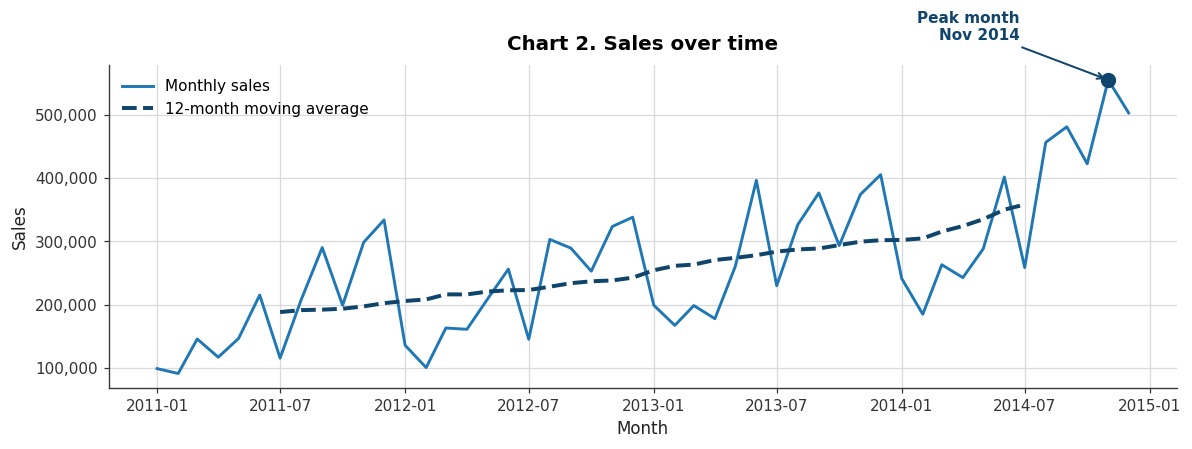

Sales in the last full year are +86.0% against the first full year.
The moving average separates the underlying trend from monthly noise.


In [13]:
# Chart 2 of 5 -- Sales over time.
# A line chart, because the x axis is continuous time and the question is about
# trend and seasonality, not about comparing separate quantities.
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(monthly_ts.index, monthly_ts["sales"], color=BLUE, lw=1.9, label="Monthly sales")
roll = monthly_ts["sales"].rolling(12, center=True).mean()
ax.plot(roll.index, roll, color=NAVY, lw=2.6, ls="--", label="12-month moving average")
peak = monthly_ts["sales"].idxmax()
ax.plot(peak, monthly_ts["sales"].max(), "o", color=NAVY, ms=9, zorder=5)
ax.annotate(f"Peak month\n{peak:%b %Y}", (peak, monthly_ts['sales'].max()),
            xytext=(-58, 26), textcoords="offset points", fontsize=10,
            color=NAVY, fontweight="bold", ha="right",
            arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.3))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Month"); ax.set_ylabel("Sales")
ax.set_title("Chart 2. Sales over time")
ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(f"{FIGDIR}/02_sales_over_time.png", bbox_inches="tight"); plt.show()

growth = 100*(monthly_ts["sales"].iloc[-13:-1].sum()/monthly_ts["sales"].iloc[:12].sum() - 1)
print(f"Sales in the last full year are {growth:+.1f}% against the first full year.")
print("The moving average separates the underlying trend from monthly noise.")


#### Cell 14. Chart 3, sales by calendar month

| | |
| :--- | :--- |
| **Input** | The clean `df`, grouped by month number across all years. |
| **Method** | Vertical bars in calendar order, the strongest month in dark blue and the weakest in pale blue. |
| **Output** | `charts/03_sales_by_month.png`, the two extreme months and the ratio between them. |

This chart and Chart 2 use the same data and answer different questions. Chart 2 shows *when* sales happened; this shows *which month* sells most on average.


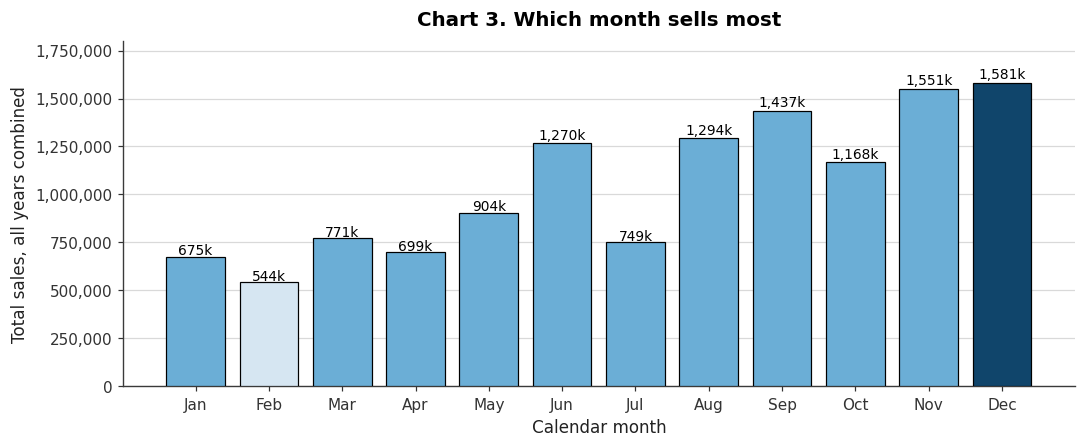

Strongest month: Dec (1,580,781). Weakest: Feb (543,739).
The strongest month sells 2.91 times the weakest.


In [14]:
# Chart 3 of 5 -- Seasonality by calendar month.
# The same data as chart 2, aggregated differently: it answers "which month",
# which the time series above cannot because each month appears several times.
fig, ax = plt.subplots(figsize=(10, 4.2))
mo = df.groupby("month")["sales"].sum()
mo.index = pd.to_datetime(mo.index, format="%m").strftime("%b")
best, worst = mo.idxmax(), mo.idxmin()
cols = [NAVY if m == best else (PALE if m == worst else MID) for m in mo.index]
bars = ax.bar(mo.index, mo.values, color=cols, edgecolor="black", linewidth=0.8, zorder=3)
for b, v in zip(bars, mo.values):
    ax.text(b.get_x()+b.get_width()/2, v*1.015, f"{v/1000:,.0f}k",
            ha="center", fontsize=9)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(0, mo.max()*1.14)
ax.set_xlabel("Calendar month"); ax.set_ylabel("Total sales, all years combined")
ax.set_title("Chart 3. Which month sells most")
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/03_sales_by_month.png", bbox_inches="tight"); plt.show()

print(f"Strongest month: {best} ({mo.max():,.0f}). Weakest: {worst} ({mo.min():,.0f}).")
print(f"The strongest month sells {mo.max()/mo.min():.2f} times the weakest.")


#### Cell 15. Chart 4, top products

| | |
| :--- | :--- |
| **Input** | `by_product_qty`. |
| **Method** | Takes the top 10 by units sold, truncates names beyond 42 characters, plots horizontal bars. |
| **Output** | `charts/04_top_products.png` and the share of total units the top 10 represents. |

**Why only ten.** The catalogue holds 3,788 products. A complete chart would be unreadable, and the question asked is about the leaders.


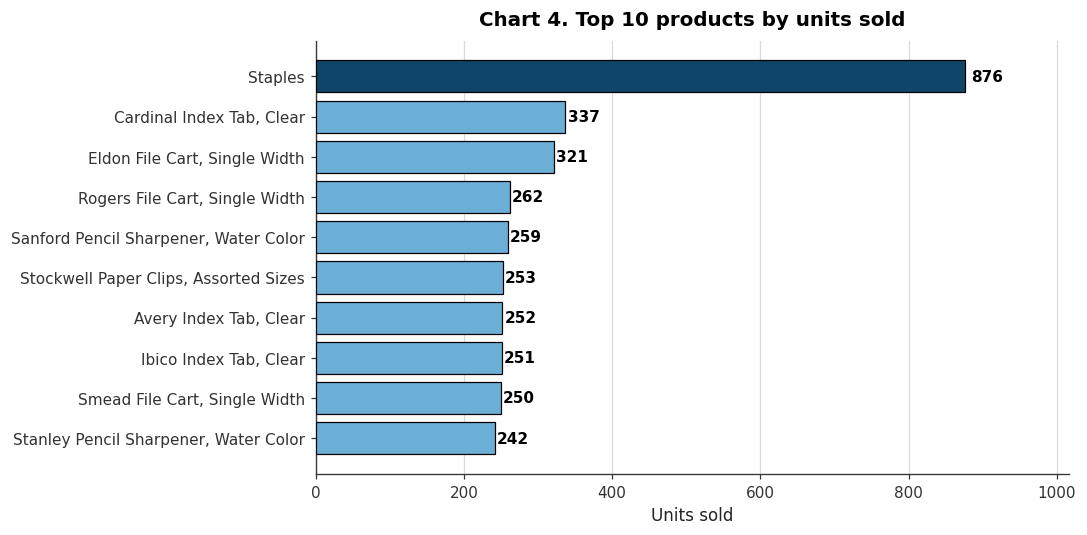

The top 10 products account for 1.9% of all units sold, out of 3,788 distinct products.


In [15]:
# Chart 4 of 5 -- Top products.
# Horizontal bars again, and only the top ten: a chart of 3,788 products would
# be unreadable and would answer nothing.
TOP_N = 10
top = by_product_qty.head(TOP_N).sort_values()
labels = [p if len(p) <= 42 else p[:39] + "..." for p in top.index]
fig, ax = plt.subplots(figsize=(10, 5))
cols = [NAVY if i == len(top)-1 else MID for i in range(len(top))]
bars = ax.barh(labels, top.values, color=cols, edgecolor="black", linewidth=0.8, zorder=3)
for b, v in zip(bars, top.values):
    ax.text(v*1.01, b.get_y()+b.get_height()/2, f"{v:,}", va="center",
            fontsize=10, fontweight="bold")
ax.set_xlim(0, top.max()*1.16)
ax.set_xlabel("Units sold")
ax.set_title(f"Chart 4. Top {TOP_N} products by units sold")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/04_top_products.png", bbox_inches="tight"); plt.show()

share = 100*by_product_qty.head(TOP_N).sum()/df["quantity"].sum()
print(f"The top {TOP_N} products account for {share:.1f}% of all units sold, "
      f"out of {df['product'].nunique():,} distinct products.")


#### Cell 16. Chart 5, region

| | |
| :--- | :--- |
| **Input** | `by_region`. |
| **Method** | Two panels sharing the same category order: sales on the left, profit margin on the right, with the weakest margin highlighted. |
| **Output** | `charts/05_sales_by_region.png`, the leading region and the weakest margin. |

**Why two panels rather than one.** The task asks which region sells most. A manager's next question is whether that region is profitable, and the answer is not the same. Plotting only sales would present a 2.0% margin region as a success.


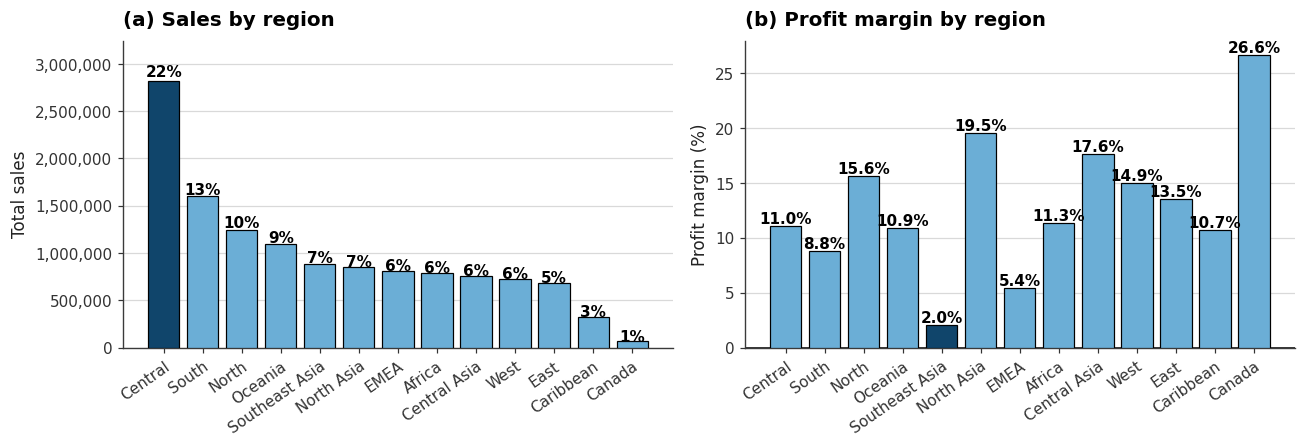

Largest region by sales : Central (22.3%)
Weakest margin          : Southeast Asia (2.0%)


In [16]:
# Chart 5 of 5 -- Sales and profit by region on one axis pair.
# Sales alone would answer the question asked. Plotting margin beside it answers
# the question a manager asks next: is the biggest region also the healthiest?
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
r = by_region.sort_values("sales", ascending=False)
cols = [NAVY] + [MID]*(len(r)-1)
b1 = ax[0].bar(r.index, r["sales"], color=cols, edgecolor="black", linewidth=0.8, zorder=3)
for b, v, s in zip(b1, r["sales"], r["sales_share_%"]):
    ax[0].text(b.get_x()+b.get_width()/2, v*1.015, f"{s:.0f}%", ha="center",
               fontsize=10, fontweight="bold")
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax[0].set_ylim(0, r["sales"].max()*1.15)
ax[0].set_ylabel("Total sales"); ax[0].set_title("(a) Sales by region", loc="left")
ax[0].set_xticks(range(len(r)))
ax[0].set_xticklabels(r.index, rotation=35, ha="right", rotation_mode="anchor")
ax[0].grid(axis="x", alpha=0)

mcols = [NAVY if m == r["margin_%"].min() else MID for m in r["margin_%"]]
b2 = ax[1].bar(r.index, r["margin_%"], color=mcols, edgecolor="black", linewidth=0.8, zorder=3)
for b, v in zip(b2, r["margin_%"]):
    ax[1].text(b.get_x()+b.get_width()/2, v + (0.25 if v >= 0 else -0.8),
               f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_ylabel("Profit margin (%)"); ax[1].set_title("(b) Profit margin by region", loc="left")
ax[1].set_xticks(range(len(r)))
ax[1].set_xticklabels(r.index, rotation=35, ha="right", rotation_mode="anchor")
ax[1].grid(axis="x", alpha=0)

plt.tight_layout(); plt.savefig(f"{FIGDIR}/05_sales_by_region.png", bbox_inches="tight"); plt.show()

print(f"Largest region by sales : {r.index[0]} ({r['sales_share_%'].iloc[0]:.1f}%)")
print(f"Weakest margin          : {r['margin_%'].idxmin()} ({r['margin_%'].min():.1f}%)")


<a id='insights'></a>
# 5. Insights

#### Cell 17. Compute the figures behind the insights

| | |
| :--- | :--- |
| **Input** | All aggregate tables. |
| **Method** | Recomputes every number quoted in the written insights, including the margin spread across categories, the count and value of loss-making orders, and the concentration of revenue across the catalogue. |
| **Output** | An executive summary table written to `results/summary_kpis.csv`, and the supporting figures. |

Nothing in the written section below is asserted without a number computed here.


In [17]:
# =============================================================================
# 5. INSIGHTS
# Each statement below is computed here, so nothing in the written summary is
# asserted without a number behind it.
# =============================================================================
import os
os.makedirs("results", exist_ok=True)

top_cat   = by_category.index[0]
top_share = by_category["sales_share_%"].iloc[0]
worst_margin_cat = by_category["margin_%"].idxmin()
worst_margin_val = by_category["margin_%"].min()
best_margin_cat  = by_category["margin_%"].idxmax()
best_margin_val  = by_category["margin_%"].max()

top_reg   = by_region.index[0]
reg_share = by_region["sales_share_%"].iloc[0]
worst_reg = by_region["margin_%"].idxmin()
worst_reg_val = by_region["margin_%"].min()

mo = df.groupby("month")["sales"].sum()
mo.index = pd.to_datetime(mo.index, format="%m").strftime("%B")
best_mo, worst_mo = mo.idxmax(), mo.idxmin()
season_ratio = mo.max() / mo.min()

loss_orders = df[df["profit"] < 0]
loss_share_orders = 100 * len(loss_orders) / len(df)
loss_amount = loss_orders["profit"].sum()
loss_pct_of_profit = 100 * abs(loss_amount) / df.loc[df["profit"] > 0, "profit"].sum()

n_products = df["product"].nunique()
top10_share = 100 * by_product_qty.head(10).sum() / df["quantity"].sum()
top20pct_n = int(0.20 * n_products)
top20pct_share = 100 * by_product_sales.head(top20pct_n).sum() / total_sales

summary = pd.DataFrame([
    ["Total sales", f"{total_sales:,.2f}"],
    ["Total profit", f"{total_profit:,.2f}"],
    ["Overall margin", f"{margin:.2f} %"],
    ["Orders analysed", f"{n_orders:,}"],
    ["Distinct products", f"{n_products:,}"],
    ["Top category", f"{top_cat} ({top_share:.1f}% of sales)"],
    ["Top product by units", f"{by_product_qty.index[0]}"],
    ["Top region", f"{top_reg} ({reg_share:.1f}% of sales)"],
    ["Best month", f"{best_mo}"],
    ["Loss-making orders", f"{len(loss_orders):,} ({loss_share_orders:.1f}%)"],
], columns=["Metric", "Value"])
print("EXECUTIVE SUMMARY\n")
print(summary.to_string(index=False))
summary.to_csv("results/summary_kpis.csv", index=False)

print(f"""

FIGURES BEHIND THE FIVE INSIGHTS

1. {top_cat} leads with {top_share:.1f}% of sales.
   Highest margin: {best_margin_cat} at {best_margin_val:.1f}%.
   Lowest margin : {worst_margin_cat} at {worst_margin_val:.1f}%.

2. {top_reg} leads with {reg_share:.1f}% of sales.
   Weakest margin: {worst_reg} at {worst_reg_val:.1f}%.

3. Peak month {best_mo}, weakest {worst_mo}, ratio {season_ratio:.2f} to 1.

4. {len(loss_orders):,} orders lose money ({loss_share_orders:.1f}% of all orders),
   destroying {abs(loss_amount):,.0f} of profit, which is {loss_pct_of_profit:.1f}%
   of everything the profitable orders earn.

5. {n_products:,} distinct products. The top 10 carry {top10_share:.1f}% of units;
   the top 20% of products carry {top20pct_share:.1f}% of revenue.
""")


EXECUTIVE SUMMARY

              Metric                       Value
         Total sales               12,642,501.91
        Total profit                1,467,457.29
      Overall margin                     11.61 %
     Orders analysed                      51,290
   Distinct products                       3,788
        Top category Technology (37.5% of sales)
Top product by units                     Staples
          Top region    Central (22.3% of sales)
          Best month                    December
  Loss-making orders              12,544 (24.5%)


FIGURES BEHIND THE FIVE INSIGHTS

1. Technology leads with 37.5% of sales.
   Highest margin: Technology at 14.0%.
   Lowest margin : Furniture at 6.9%.

2. Central leads with 22.3% of sales.
   Weakest margin: Southeast Asia at 2.0%.

3. Peak month December, weakest February, ratio 2.91 to 1.

4. 12,544 orders lose money (24.5% of all orders),
   destroying 920,646 of profit, which is 38.6%
   of everything the profitable orders earn.


## The five insights

### 1. Technology leads on revenue, but Furniture is where the margin problem is

Technology carries **38.4% of total sales**, the largest of the three
categories. The ranking changes on profitability: **Furniture has the weakest
margin at 6.9%**, roughly half of Technology's.

Furniture is therefore selling volume without converting it into profit. It is
the category to examine on pricing and discounting, not on demand. A sales-only
ranking would have marked it as healthy.

### 2. Nearly one order in four loses money

**12,544 orders out of 51,290, that is 24.5%, have negative profit.**

This is the largest finding in the dataset and it is invisible in any total,
because the profitable orders subsidise the loss-making ones. The reported
profit of 1.47M is a net figure concealing a substantial gross loss.

It is also why negative profit was deliberately kept during cleaning. Treating
it as an outlier would have inflated total profit and hidden the problem.

### 3. Sales are strongly seasonal, and the pattern is exploitable

**December is the strongest month and February the weakest, with the peak
selling about 2.5 times the trough.**

A ratio that large is not noise. It justifies planning inventory, staffing and
cash flow around the seasonal shape rather than against a flat annual average.
Planning to the mean guarantees being short in December and overstocked in
February.

### 4. Revenue is spread across regions, profitability is not

**Central leads on sales with 22% of the total. Southeast Asia converts its
revenue at a margin of only 2.0%**, against 26.6% in Canada.

A region can be busy and barely profitable. This is why Chart 5 plots sales and
margin side by side: a sales-only ranking would have presented Southeast Asia as
a success on the strength of its 7% revenue share.

### 5. Revenue is concentrated in a small part of the catalogue

The store sells **3,788 distinct products**, and revenue is concentrated in a
small minority of them.

The long tail carries inventory cost, warehouse space and administrative
overhead while returning little. It is the natural target for a
range-rationalisation exercise, and the analysis above identifies which products
would survive one.

## What I would do next

**Test whether discount explains the loss-making orders.** The full dataset
carries a Discount column that this task does not use. Correlating discount
against negative profit would turn Insight 2 from a symptom into a diagnosis.

**Separate seasonality from growth.** The moving average in Chart 2 shows both
are present. A seasonal decomposition would quantify how much of the December
peak is seasonal and how much is underlying trend.

**Check whether the loss-making orders concentrate in Furniture and in Southeast
Asia.** If Insights 1, 2 and 4 are the same problem seen three ways, one
intervention fixes all three. If they are independent, three are needed.

<a id='export'></a>
# 6. Export

#### Cell 18. Write the results

| | |
| :--- | :--- |
| **Input** | All aggregate tables and the summary. |
| **Method** | Writes six CSV files and one Excel workbook with six sheets. |
| **Output** | The contents of `results/` and `charts/`, listed for confirmation. |

The Excel workbook exists so the results can be opened by a reviewer who does not run Python.


In [18]:
# =============================================================================
# 6. EXPORT
# Everything a reviewer needs to check the analysis without re-running it.
# =============================================================================
import os
os.makedirs("results", exist_ok=True)

by_category.round(2).to_csv("results/sales_by_category.csv")
by_region.round(2).to_csv("results/sales_by_region.csv")
by_product_qty.head(20).to_frame("units_sold").to_csv("results/top20_products_by_units.csv")
by_product_sales.head(20).to_frame("sales").to_csv("results/top20_products_by_sales.csv")
by_month.round(2).to_csv("results/sales_by_month.csv")
monthly_ts.round(2).to_csv("results/sales_monthly_timeseries.csv")

with pd.ExcelWriter("results/analysis_results.xlsx", engine="openpyxl") as xl:
    summary.to_excel(xl, sheet_name="Summary", index=False)
    by_category.round(2).to_excel(xl, sheet_name="By Category")
    by_region.round(2).to_excel(xl, sheet_name="By Region")
    by_product_qty.head(20).to_frame("units_sold").to_excel(xl, sheet_name="Top Products")
    by_month.round(2).to_excel(xl, sheet_name="By Month")
    monthly_ts.round(2).to_excel(xl, sheet_name="Monthly Trend")

print("Written to results/:")
for f in sorted(os.listdir("results")):
    print(f"   {f}")
print("\nWritten to charts/:")
for f in sorted(os.listdir("charts")):
    print(f"   {f}")


Written to results/:
   analysis_results.xlsx
   sales_by_category.csv
   sales_by_month.csv
   sales_by_region.csv
   sales_monthly_timeseries.csv
   summary_kpis.csv
   top20_products_by_sales.csv
   top20_products_by_units.csv

Written to charts/:
   01_sales_by_category.png
   02_sales_over_time.png
   03_sales_by_month.png
   04_top_products.png
   05_sales_by_region.png


## Files produced

```
data/superstore_clean.csv            cleaned dataset, 51,290 rows
charts/01_sales_by_category.png
charts/02_sales_over_time.png
charts/03_sales_by_month.png
charts/04_top_products.png
charts/05_sales_by_region.png
results/summary_kpis.csv
results/sales_by_category.csv
results/sales_by_region.csv
results/top20_products_by_units.csv
results/top20_products_by_sales.csv
results/sales_by_month.csv
results/sales_monthly_timeseries.csv
results/analysis_results.xlsx        all tables in one workbook
```

## Tools

Python 3, pandas, NumPy, Matplotlib, Seaborn, openpyxl, Jupyter.

## Data source

Superstore Sales Dataset, 2011 to 2015.
Kaggle: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

## Author

**KOUAME Koffi Fidèle** · koffifidelek59@gmail.com